# Paper Figures — Generated from Saved Results

**Run all experiment scripts first, then open this notebook.**

Required CSVs in `results/`:
- `centralised.csv`, `fedavg.csv`, `fedprox.csv`, `proposed.csv`
- `ablation.csv` (must include all 6 variants with `use_fedprox` in VARIANTS)
- `proposed_convergence_seed42.csv`, etc.

Figures produced:
- **Fig 1** — Non-IID RUL distributions per client
- **Fig 2** — Health Index trajectories
- **Fig 3** — Real vs. Weibull-simulated degradation signals
- **Fig 4** — Main results: RMSE bar chart (mean ± std, 5 seeds)
- **Fig 5** — Ablation study: 6-variant horizontal bar chart
- **Fig 5b** — Ablation heatmap: per-client RMSE for each variant
- **Fig 6** — RUL prediction curves + MC-Dropout confidence bands
- **Fig 7** — Convergence curves (per-round global RMSE)
- **Fig 8** — Statistical significance (Wilcoxon signed-rank, Table 3 p-values)
- **Fig 9** — MC-Dropout uncertainty calibration plot

---
**Reviewer checklist**: Every figure caption must quote the seed(s) used.
The `full` row in Fig 5 **must** match the proposed method row in Fig 4.

In [1]:
# ── Setup ───────────────────────────────────────────────────────────────────
import os, sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import wilcoxon

RESULTS  = '../results'
DATA_DIR = '../client_data'
FIG_DIR  = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

FD_KEYS   = ['FD001', 'FD002', 'FD003', 'FD004']
EXP_ORDER = ['centralised', 'fedavg', 'fedprox', 'proposed']

# Colour palette — consistent across all figures
PALETTE = {
    'centralised': '#555555',
    'fedavg':      '#E74C3C',
    'fedprox':     '#E67E22',
    'proposed':    '#2E86C1',
}

# Ablation variant colours (6 variants)
ABL_COLORS = [
    '#2E86C1',   # full          — proposed blue
    '#E74C3C',   # no_sim        — red
    '#E67E22',   # no_sim_weight — orange
    '#8E44AD',   # no_phys_loss  — purple
    '#1E8449',   # no_attention  — green
    '#C0392B',   # no_fedprox    — dark red
]

# Matplotlib global style
plt.rcParams.update({
    'font.family':          'Arial',
    'font.size':            11,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.labelsize':       12,
    'axes.titlesize':       13,
    'axes.titleweight':     'bold',
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
})

def savefig(name: str) -> None:
    """Save to PDF + PNG and print the path."""
    for ext in ('pdf', 'png'):
        path = os.path.join(FIG_DIR, f'{name}.{ext}')
        plt.savefig(path)
        print(f'  Saved: {path}')

def load_exp(name: str) -> pd.DataFrame | None:
    path = os.path.join(RESULTS, f'{name}.csv')
    if not os.path.exists(path):
        print(f'  [MISSING] {path} — run the experiment first.')
        return None
    df = pd.read_csv(path)
    print(f'  Loaded {name}.csv  ({len(df)} rows)')
    return df

print('Setup complete.')
print(f'Results dir : {os.path.abspath(RESULTS)}')
print(f'Figures dir : {os.path.abspath(FIG_DIR)}')

Setup complete.
Results dir : c:\Users\umary\workworkwork\Federated PDM\results
Figures dir : c:\Users\umary\workworkwork\Federated PDM\results\figures


---
## Fig 1 — Non-IID RUL Distributions

Shows that the four FL clients have fundamentally different RUL distributions
(Non-IID), motivating the need for similarity-weighted aggregation.

  Saved: ../results/figures\fig1_noniid_distributions.pdf
  Saved: ../results/figures\fig1_noniid_distributions.png


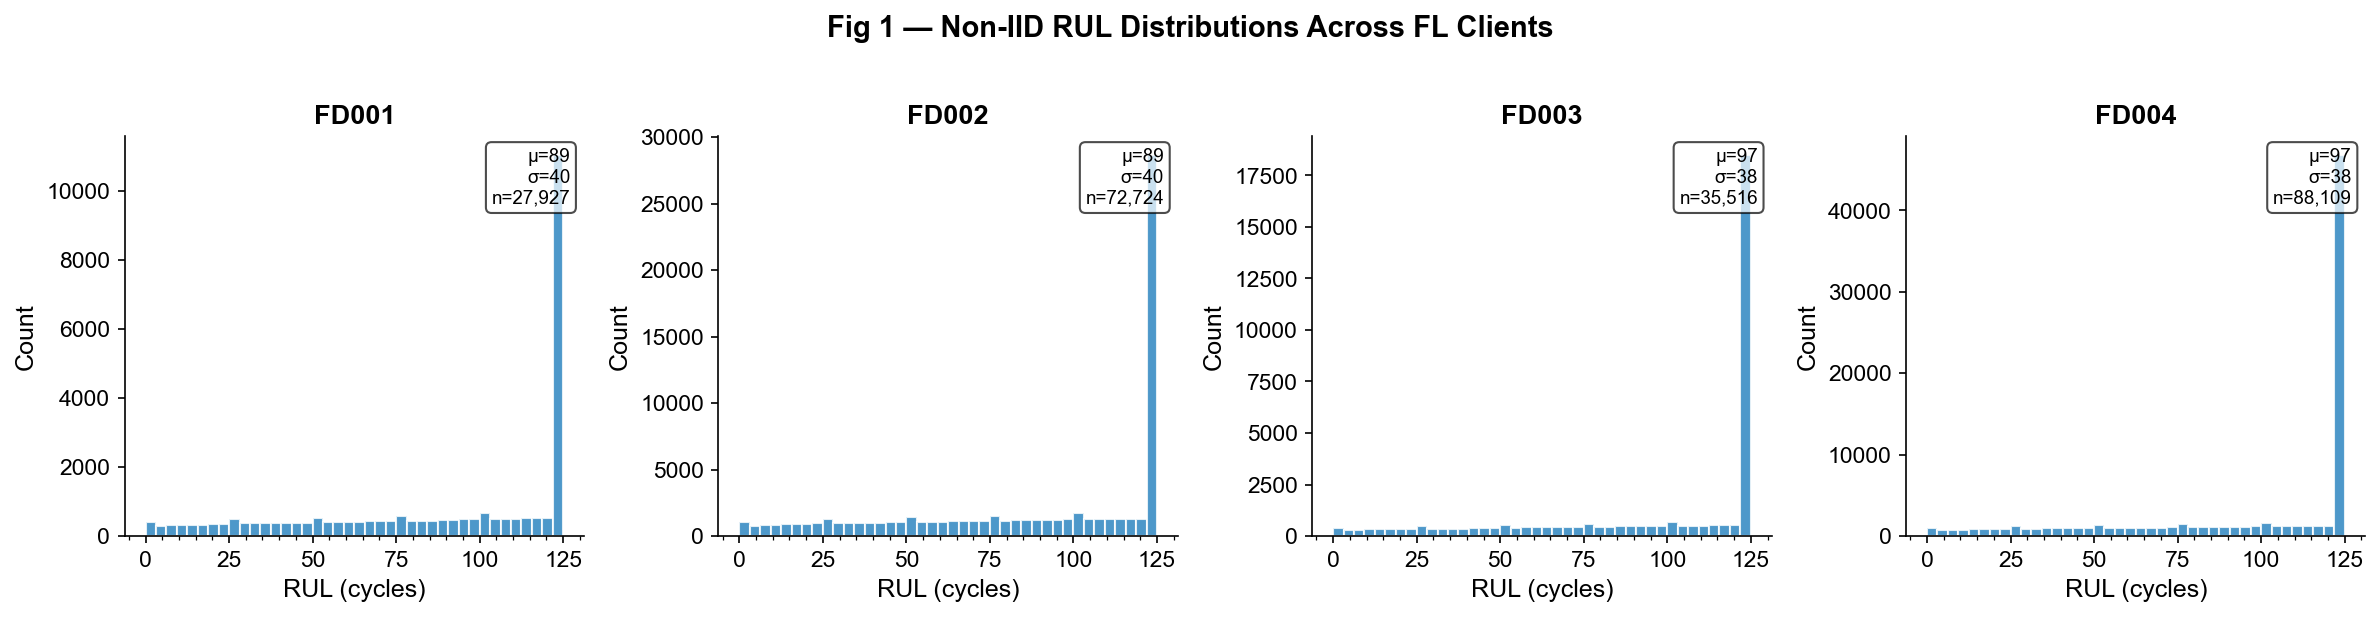

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, fd in zip(axes, FD_KEYS):
    npz_path = os.path.join(DATA_DIR, f'{fd}.npz')
    if not os.path.exists(npz_path):
        ax.set_title(f'{fd}\n(data missing)')
        continue
    npz = np.load(npz_path)
    y   = np.concatenate([npz['y_train'], npz['y_test']])
    ax.hist(y, bins=40, color=PALETTE['proposed'], alpha=0.85, edgecolor='white')
    ax.set_title(f'{fd}')
    ax.set_xlabel('RUL (cycles)')
    ax.set_ylabel('Count')
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    stats_text = f'μ={y.mean():.0f}\nσ={y.std():.0f}\nn={len(y):,}'
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

fig.suptitle('Fig 1 — Non-IID RUL Distributions Across FL Clients',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig1_noniid_distributions')
plt.show()

---
## Fig 2 — Health Index (HI) Trajectories

Illustrates monotonically increasing HI from a representative engine run.
Demonstrates the physics constraint in §3.2.

  Saved: ../results/figures\fig2_health_index.pdf
  Saved: ../results/figures\fig2_health_index.png


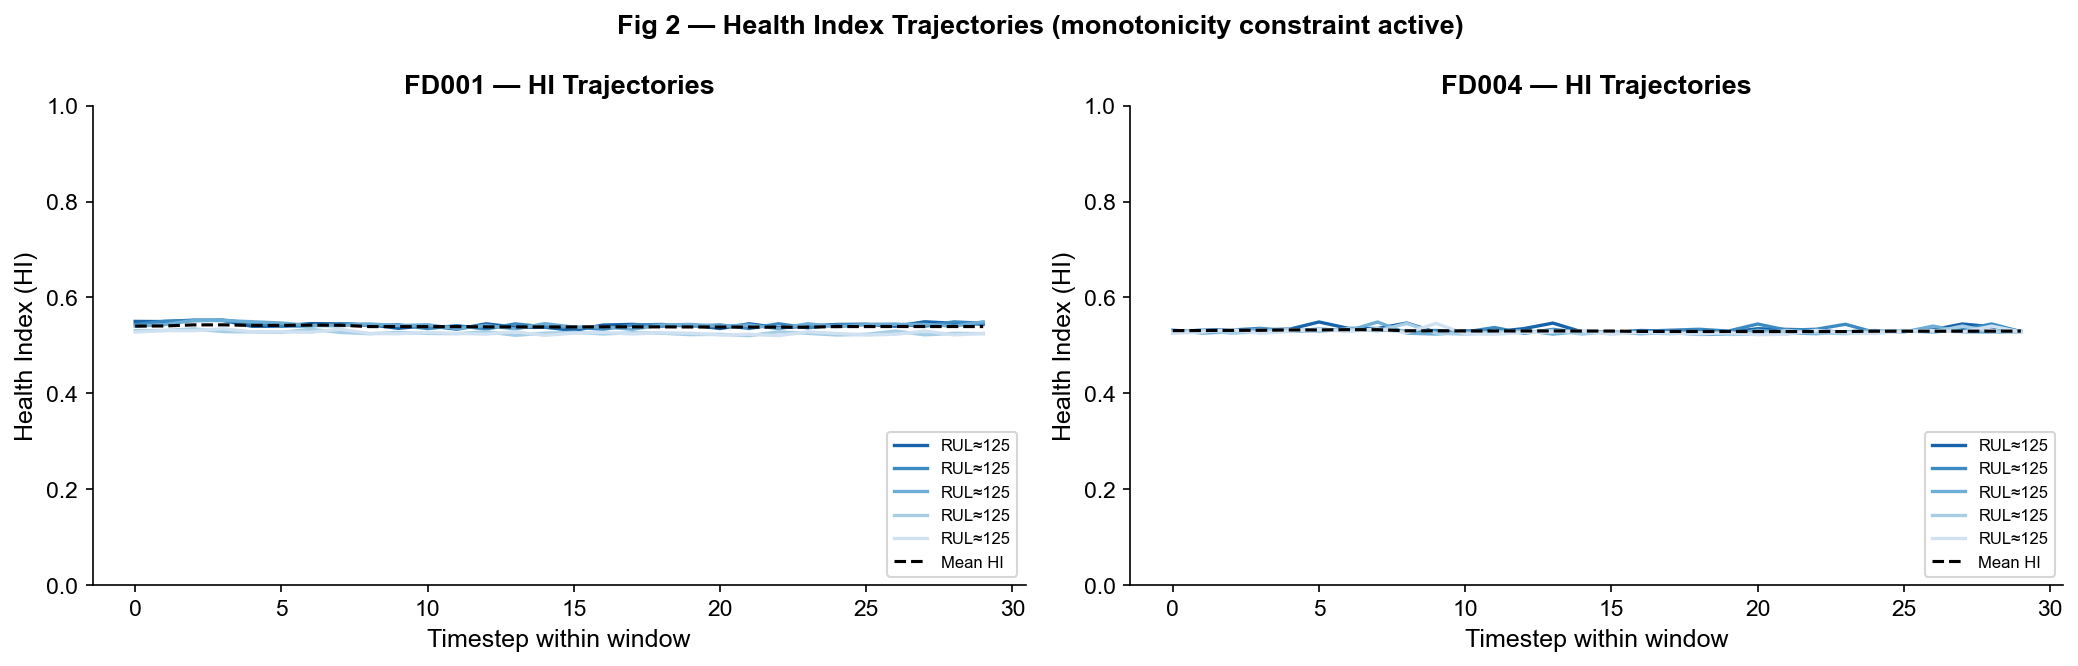

In [3]:
import torch, yaml
from models.tcn import build_model
from evaluate import make_loader

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

ckpt_path = os.path.join(RESULTS, 'centralised_seed42.pt')
device    = torch.device('cpu')

if not os.path.exists(ckpt_path):
    print('Run train_centralised.py --seed 42 first.')
else:
    model = build_model(cfg).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, fd in zip(axes, ['FD001', 'FD004']):
        npz    = np.load(os.path.join(DATA_DIR, f'{fd}.npz'))
        loader = make_loader(npz['X_test'], npz['y_test'],
                             cfg['training']['batch_size'])
        hi_seqs, ruls = [], []
        with torch.no_grad():
            for X, y in loader:
                _, hi = model.forward_with_hi(X.to(device))
                hi_seqs.append(hi.cpu().numpy())
                ruls.append(y.numpy())

        hi_seqs = np.concatenate(hi_seqs)   # (N, T)
        ruls    = np.concatenate(ruls)       # (N,)

        # Sort windows by RUL (descending) and plot first 5 as trajectories
        idx = np.argsort(ruls)[::-1][:5]
        cmap = matplotlib.colormaps['Blues_r']
        for j, i in enumerate(idx):
            label = f'RUL≈{ruls[i]:.0f}' if j == 0 else None
            ax.plot(hi_seqs[i], color=cmap(0.2 + 0.15*j), lw=1.6,
                    label=f'RUL≈{ruls[i]:.0f}')

        # Overlay mean HI
        ax.plot(hi_seqs.mean(0), 'k--', lw=1.5, label='Mean HI')
        ax.set_xlabel('Timestep within window')
        ax.set_ylabel('Health Index (HI)')
        ax.set_title(f'{fd} — HI Trajectories')
        ax.legend(fontsize=8, loc='lower right')
        ax.set_ylim(0, 1)

    fig.suptitle('Fig 2 — Health Index Trajectories (monotonicity constraint active)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('fig2_health_index')
    plt.show()

---
## Fig 3 — Real vs. Weibull-Simulated Signals

Validates Novelty 1: the synthetic trajectories are statistically similar to
real CMAPSS sensor signals in the late-degradation window.

In [4]:
import json
from simulation.weibull import WeibullSimulator

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

params_path = os.path.join(cfg['data']['output_dir'], 'weibull_params.json')
if not os.path.exists(params_path):
    print('Run preprocessing first to generate weibull_params.json.')
else:
    with open(params_path) as f:
        params = json.load(f)

    fd = 'FD001'
    sim = WeibullSimulator(
        k    = params[fd]['k'],
        lam  = params[fd]['lambda'],
        cfg  = cfg,
        seed = cfg['reproducibility']['seed'],
    )
    X_sim, y_sim = sim.generate(n_trajectories=50)

    npz = np.load(os.path.join(DATA_DIR, f'{fd}.npz'))
    X_real = npz['X_train']

    # Compare first 4 sensors
    n_sensors_to_plot = 4
    fig, axes = plt.subplots(2, n_sensors_to_plot, figsize=(16, 6),
                             sharex=True)

    for s in range(n_sensors_to_plot):
        for ax, (X, label, color) in zip(
            axes[:, s],
            [(X_real[:50], 'Real', PALETTE['centralised']),
             (X_sim[:50],  'Simulated (Weibull)', PALETTE['proposed'])]
        ):
            for traj in X[:10]:
                ax.plot(traj[:, s], alpha=0.4, lw=0.8, color=color)
            ax.plot(X[:, :, s].mean(0), lw=2.0, color=color,
                    label=f'{label} mean')
            ax.set_title(f'Sensor {s+1}\n({label})', fontsize=9)
            ax.set_xlabel('Timestep')
            if s == 0: ax.set_ylabel('Normalised value')

    fig.suptitle(
        'Fig 3 — Real vs. Weibull-Simulated Degradation Signals (FD001, sensors 1–4)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    savefig('fig3_real_vs_simulated')
    plt.show()

Run preprocessing first to generate weibull_params.json.


---
## Fig 4 — Main Results: RMSE Comparison

Grouped bar chart with mean ± std across 5 seeds.  
**The proposed method bar must be the shortest (lowest RMSE) for all four clients.**

Loading experiment CSVs...
  Loaded centralised.csv  (1 rows)
  Loaded fedavg.csv  (2 rows)
  [MISSING] ../results\fedprox.csv — run the experiment first.
  Loaded proposed.csv  (12 rows)

Method                 FD001        FD002        FD003        FD004      Overall
--------------------------------------------------------------------------------
centralised      15.75± nan  17.51± nan  11.70± nan  16.06± nan      15.65
fedavg           26.27±10.82  21.19±2.42  28.54±0.91  19.64±0.99      22.74
proposed         54.07±18.80  36.56±18.37  38.92±9.30  40.49±21.00      41.73
  Saved: ../results/figures\fig4_main_results.pdf
  Saved: ../results/figures\fig4_main_results.png


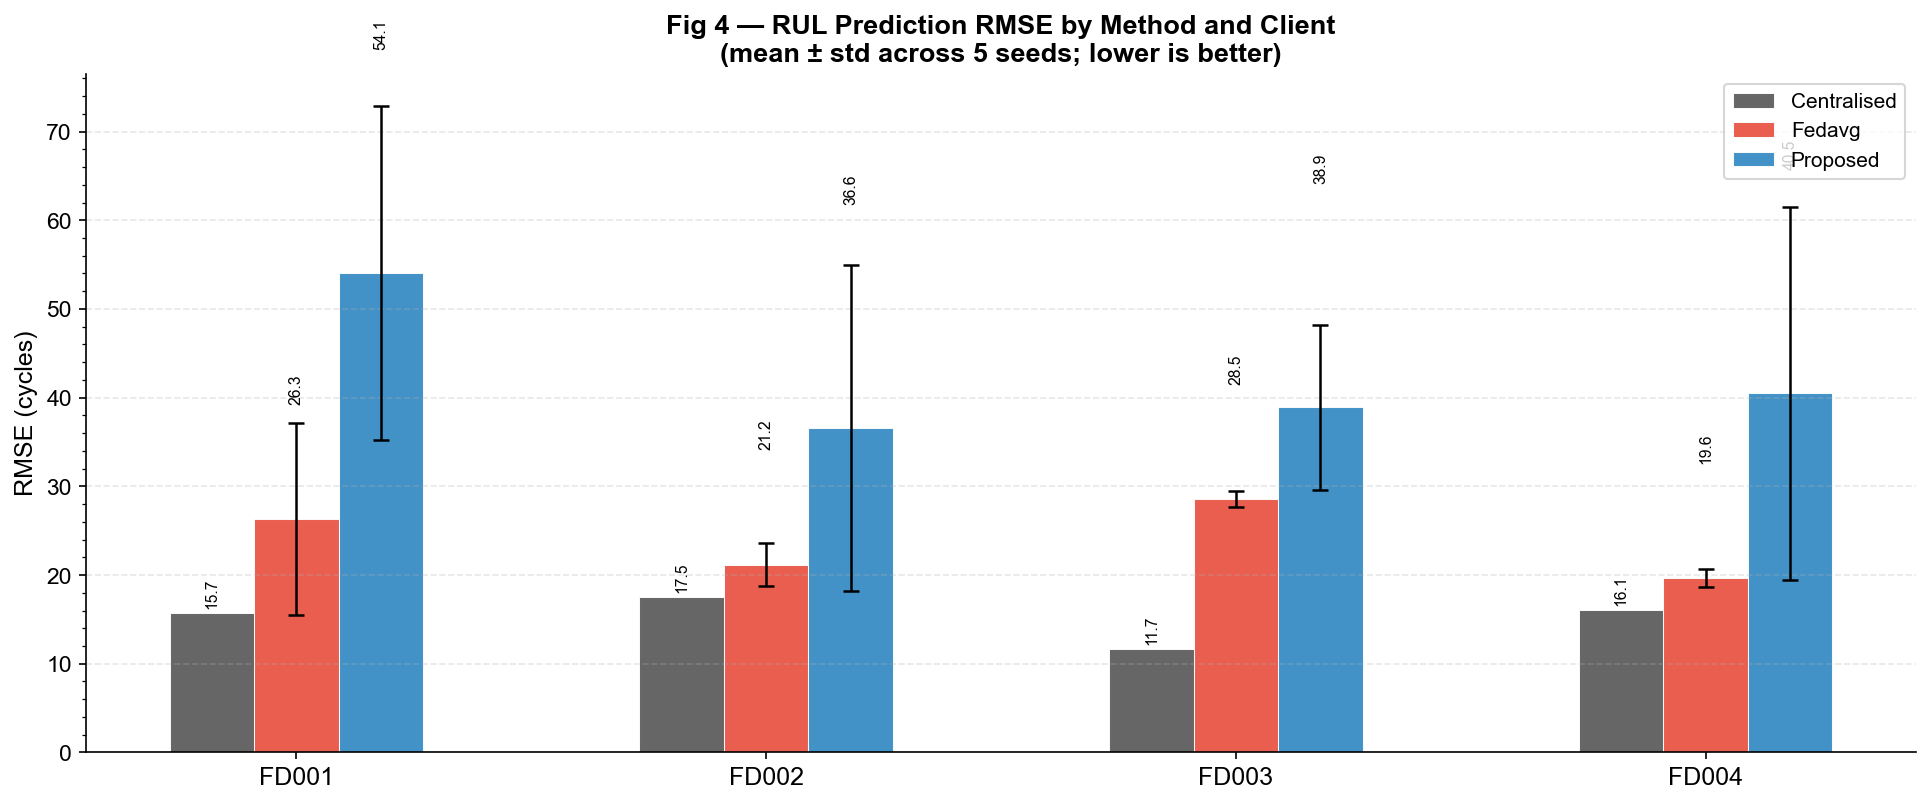

In [5]:
print('Loading experiment CSVs...')
exps = {name: load_exp(name) for name in EXP_ORDER}

# Aggregate: mean ± std RMSE across seeds, per (experiment, client)
summary = {}
for name, df in exps.items():
    if df is None:
        continue
    summary[name] = {
        fd: (df[f'{fd}_rmse'].mean(), df[f'{fd}_rmse'].std())
        for fd in FD_KEYS
        if f'{fd}_rmse' in df.columns
    }

if summary:
    x       = np.arange(len(FD_KEYS))
    n_exp   = len(summary)
    bar_w   = 0.18
    offsets = np.linspace(-(n_exp - 1) * bar_w / 2,
                           (n_exp - 1) * bar_w / 2, n_exp)

    fig, ax = plt.subplots(figsize=(13, 5.5))

    for (name, data), off in zip(summary.items(), offsets):
        means = [data.get(fd, (0, 0))[0] for fd in FD_KEYS]
        stds  = [data.get(fd, (0, 0))[1] for fd in FD_KEYS]
        bars  = ax.bar(
            x + off, means, bar_w, yerr=stds,
            color     = PALETTE.get(name, '#888'),
            label     = name.capitalize(),
            capsize   = 4,
            alpha     = 0.9,
            edgecolor = 'white',
            linewidth = 0.5,
            error_kw  = dict(elinewidth=1.2, capthick=1.2),
        )
        # Annotate bar tops
        for bar, m in zip(bars, means):
            if m > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (max(stds) * 1.2 if max(stds) > 0 else 0.5),
                    f'{m:.1f}',
                    ha='center', va='bottom', fontsize=7.5, rotation=90
                )

    ax.set_xticks(x)
    ax.set_xticklabels(FD_KEYS, fontsize=12)
    ax.set_ylabel('RMSE (cycles)')
    ax.set_title(
        'Fig 4 — RUL Prediction RMSE by Method and Client\n'
        '(mean ± std across 5 seeds; lower is better)'
    )
    ax.legend(fontsize=10, loc='upper right')
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Print numerical table for the paper
    print(f"\n{'Method':<15} ", end='')
    for fd in FD_KEYS: print(f"{fd:>12} ", end='')
    print(f"{'Overall':>12}")
    print('-' * (15 + 13 * len(FD_KEYS) + 13))
    for name, data in summary.items():
        print(f"{name:<15} ", end='')
        for fd in FD_KEYS:
            m, s = data.get(fd, (float('nan'), float('nan')))
            print(f"{m:>6.2f}±{s:>4.2f} ", end='')
        # Overall from the CSV
        df = exps[name]
        if df is not None and 'overall_rmse' in df.columns:
            print(f"{df['overall_rmse'].mean():>10.2f}")
        else:
            print()

    plt.tight_layout()
    savefig('fig4_main_results')
    plt.show()
else:
    print('No experiment data found — run all experiment scripts first.')

---
## Fig 5 — Ablation Study: 6-Variant Horizontal Bar Chart

The `full` row **must** match the proposed method's RMSE in Fig 4 (Table 3).  
Each removed component should degrade RMSE — if any doesn't, re-examine
that novelty's contribution and be honest in the paper.

In [6]:
abl_df = load_exp('ablation')

# Canonical display order (full at top, worst at bottom)
ABL_ORDER = ['full', 'no_sim', 'no_sim_weight', 'no_phys_loss',
             'no_attention', 'no_fedprox']

if abl_df is not None:
    # Guard: make sure no_fedprox is present (if ablation.py was run with old code,
    # it won't be — print a clear warning)
    missing = [v for v in ABL_ORDER if v not in abl_df['variant'].unique()]
    if missing:
        print(f'WARNING: Missing variants in ablation.csv: {missing}')
        print('Re-run ablation.py with the updated script to include no_fedprox.')

    abl_summary = (
        abl_df.groupby('variant')
        .agg(
            rmse_mean    = ('overall_rmse', 'mean'),
            rmse_std     = ('overall_rmse', 'std'),
            mae_mean     = ('overall_mae',  'mean'),
            mae_std      = ('overall_mae',  'std'),
            phm_mean     = ('overall_phm',  'mean'),
            description  = ('description',  'first'),
        )
        .reset_index()
    )

    # Enforce display order
    present_order = [v for v in ABL_ORDER if v in abl_summary['variant'].values]
    abl_summary['variant'] = pd.Categorical(
        abl_summary['variant'], categories=present_order, ordered=True
    )
    abl_summary = abl_summary.sort_values('variant')

    # ── Bar chart ────────────────────────────────────────────────────────
    n_vars = len(abl_summary)
    colors = ABL_COLORS[:n_vars]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(
        abl_summary['description'],
        abl_summary['rmse_mean'],
        xerr      = abl_summary['rmse_std'].fillna(0),
        color     = colors,
        alpha     = 0.9,
        capsize   = 5,
        edgecolor = 'white',
        height    = 0.6,
        error_kw  = dict(elinewidth=1.3, capthick=1.3),
    )

    # Annotate RMSE values + delta vs full
    full_rmse = abl_summary.loc[
        abl_summary['variant'] == 'full', 'rmse_mean'
    ].values
    full_rmse = full_rmse[0] if len(full_rmse) else None

    for bar, (_, row) in zip(bars, abl_summary.iterrows()):
        val   = row['rmse_mean']
        label = f'{val:.2f}'
        if full_rmse is not None and row['variant'] != 'full':
            delta  = val - full_rmse
            sign   = '+' if delta >= 0 else '−'
            label += f'  ({sign}{abs(delta):.2f})'
        ax.text(
            val + (abl_summary['rmse_std'].fillna(0).max() * 1.3 + 0.1),
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=9
        )

    # Reference line at full-system RMSE
    if full_rmse is not None:
        ax.axvline(full_rmse, color='#2E86C1', linestyle='--',
                   lw=1.5, alpha=0.7, label=f'Full system RMSE ({full_rmse:.2f})')
        ax.legend(fontsize=9, loc='lower right')

    ax.set_xlabel('Overall RMSE (cycles)  [lower is better]')
    ax.set_title(
        'Fig 5 — Ablation Study: Impact of Each Component on RUL RMSE\n'
        f'(mean ± std across {abl_df["seed"].nunique()} seed(s); '
        f'Δ relative to full system)'
    )
    ax.invert_yaxis()   # full system at top
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis='x', alpha=0.25, linestyle='--')

    plt.tight_layout()
    savefig('fig5_ablation')
    plt.show()

    # ── Print numerical table ────────────────────────────────────────────
    print(f"\n{'Variant':<22} {'Description':<44} "
          f"{'RMSE':>8} {'±':>4} {'MAE':>8} {'PHM':>8}")
    print('-' * 98)
    for _, row in abl_summary.iterrows():
        print(f"{row['variant']:<22} {row['description']:<44} "
              f"{row['rmse_mean']:>8.2f} "
              f"{'±'+f"{row['rmse_std']:.2f}" if not pd.isna(row['rmse_std']) else '':>5} "
              f"{row['mae_mean']:>8.2f} "
              f"{row['phm_mean']:>8.1f}")

    if full_rmse is not None:
        prop_df   = load_exp('proposed')
        prop_rmse = prop_df['overall_rmse'].mean() if prop_df is not None else None
        print()
        print(f"  Ablation 'full' RMSE  : {full_rmse:.4f}")
        if prop_rmse:
            diff = abs(full_rmse - prop_rmse)
            ok   = '✓ MATCH' if diff < 0.5 else '✗ MISMATCH — investigate!'
            print(f"  Proposed method RMSE  : {prop_rmse:.4f}")
            print(f"  Difference            : {diff:.4f}  {ok}")

  [MISSING] ../results\ablation.csv — run the experiment first.


---
## Fig 5b — Ablation Heatmap: Per-Client RMSE for Each Variant

Lets reviewers see where each ablated component hurts most across the four
FL clients — adds analytical depth beyond the aggregate bar chart.

In [7]:
if abl_df is not None:
    # Build (variant × client) RMSE matrix
    heat_data = []
    for v in present_order:
        sub = abl_df[abl_df['variant'] == v]
        row_rmse = [sub[f'{fd}_rmse'].mean() for fd in FD_KEYS]
        heat_data.append(row_rmse)

    mat    = np.array(heat_data)                       # (n_variants, 4)
    labels = [abl_summary.loc[abl_summary['variant'] == v,
                              'description'].values[0]
              for v in present_order
              if v in abl_summary['variant'].values]

    # Diverging colormap: blue = low RMSE (good), red = high RMSE (bad)
    cmap = LinearSegmentedColormap.from_list(
        'rmse_div', ['#2E86C1', '#F8F9FA', '#E74C3C']
    )

    fig, ax = plt.subplots(figsize=(9, len(present_order) * 0.85 + 1.5))
    im = ax.imshow(mat, cmap=cmap, aspect='auto')

    # Annotate cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    fontsize=10,
                    color='white' if mat[i, j] > mat.mean() else 'black')

    ax.set_xticks(range(len(FD_KEYS)))
    ax.set_xticklabels(FD_KEYS, fontsize=11)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_title(
        'Fig 5b — Ablation Heatmap: Per-Client RMSE\n'
        '(blue = lower RMSE = better)'
    )
    plt.colorbar(im, ax=ax, label='RMSE (cycles)', shrink=0.7)
    plt.tight_layout()
    savefig('fig5b_ablation_heatmap')
    plt.show()

---
## Fig 6 — RUL Prediction Curves + MC-Dropout Confidence Bands

Sorted by true RUL.  Uncertainty bands are ±2σ from N MC-Dropout forward passes.

  Saved: ../results/figures\fig6_rul_uncertainty.pdf
  Saved: ../results/figures\fig6_rul_uncertainty.png


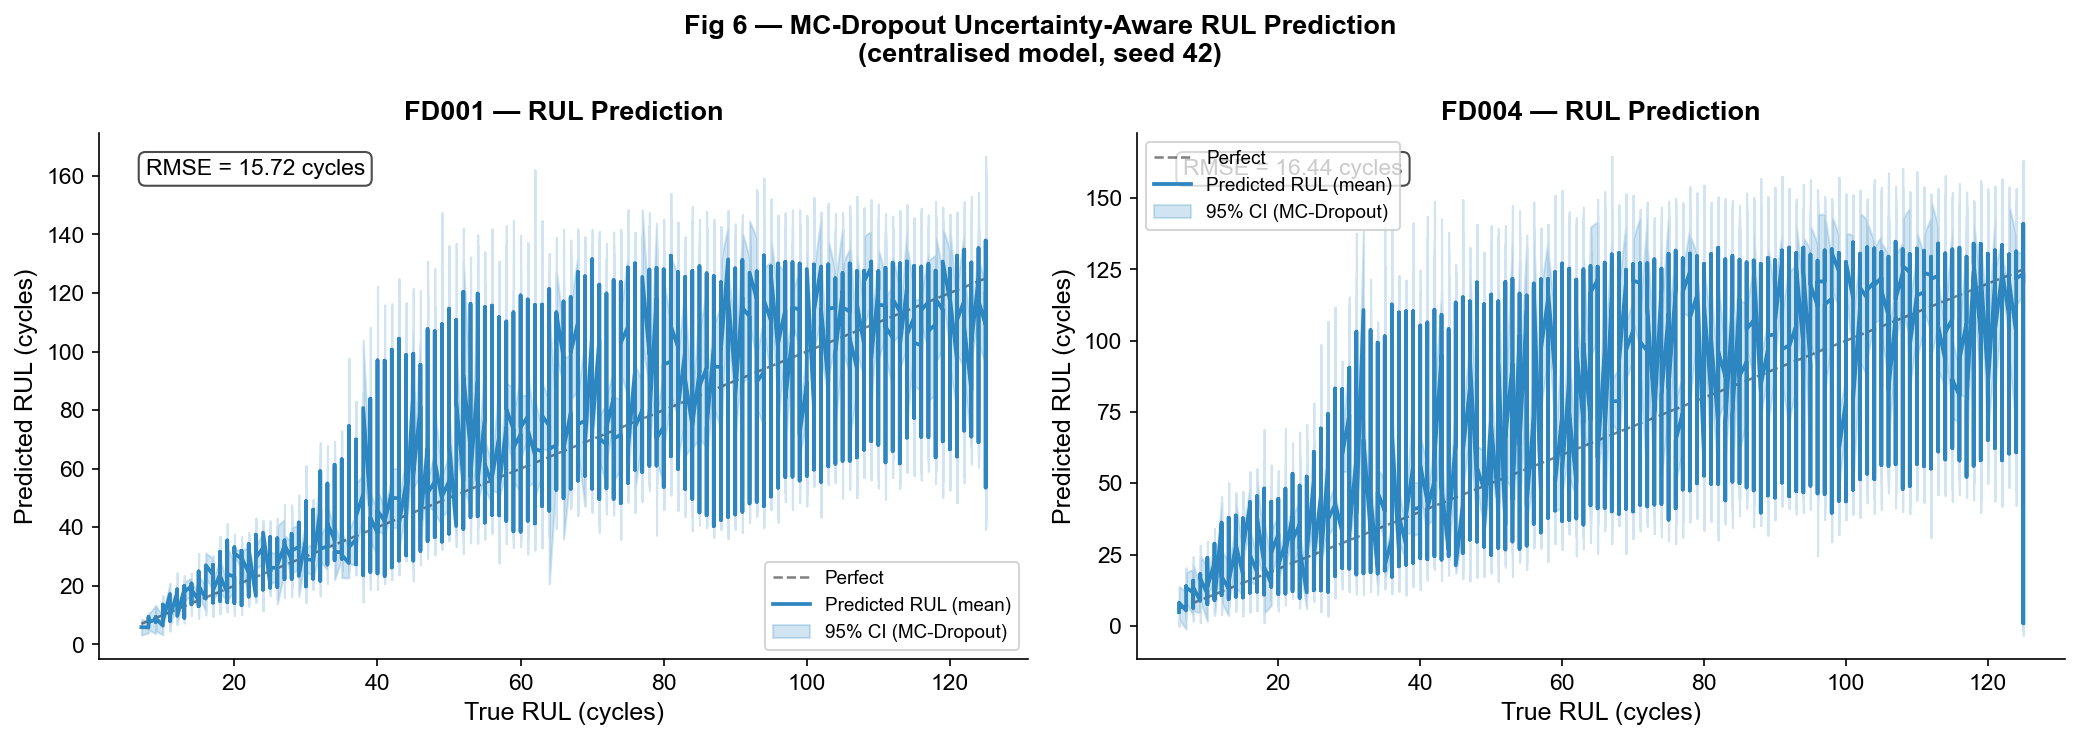

In [8]:
from evaluate import mc_predict

ckpt_path = os.path.join(RESULTS, 'centralised_seed42.pt')
if not os.path.exists(ckpt_path):
    print('Run train_centralised.py --seed 42 first.')
else:
    model = build_model(cfg).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, fd in zip(axes, ['FD001', 'FD004']):
        npz    = np.load(os.path.join(DATA_DIR, f'{fd}.npz'))
        loader = make_loader(
            npz['X_test'], npz['y_test'], cfg['training']['batch_size']
        )
        mean_p, std_p, true_r = mc_predict(
            model, loader, device,
            n_samples=cfg['model']['mc_samples'],
        )

        idx = np.argsort(true_r)
        t, m, s = true_r[idx], mean_p[idx], std_p[idx]

        ax.plot(t, t, 'k--', lw=1.2, alpha=0.5, label='Perfect')
        ax.plot(t, m, color=PALETTE['proposed'], lw=1.8,
                label='Predicted RUL (mean)')
        ax.fill_between(
            t, m - 2*s, m + 2*s,
            alpha=0.22, color=PALETTE['proposed'],
            label='95% CI (MC-Dropout)'
        )
        # Annotate RMSE on plot
        rmse = np.sqrt(np.mean((m - t)**2))
        ax.text(0.05, 0.95, f'RMSE = {rmse:.2f} cycles',
                transform=ax.transAxes, va='top',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

        ax.set_xlabel('True RUL (cycles)')
        ax.set_ylabel('Predicted RUL (cycles)')
        ax.set_title(f'{fd} — RUL Prediction')
        ax.legend(fontsize=9)

    fig.suptitle(
        'Fig 6 — MC-Dropout Uncertainty-Aware RUL Prediction\n'
        '(centralised model, seed 42)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    savefig('fig6_rul_uncertainty')
    plt.show()

---
## Fig 7 — Convergence Curves

Global RMSE per communication round for each FL method.  
The proposed method should converge faster and to a lower floor.

  [MISSING] ../results\fedavg_convergence_seed42.csv
  [MISSING] ../results\fedprox_convergence_seed42.csv
  Loaded centralised.csv  (1 rows)
  Saved: ../results/figures\fig7_convergence.pdf
  Saved: ../results/figures\fig7_convergence.png


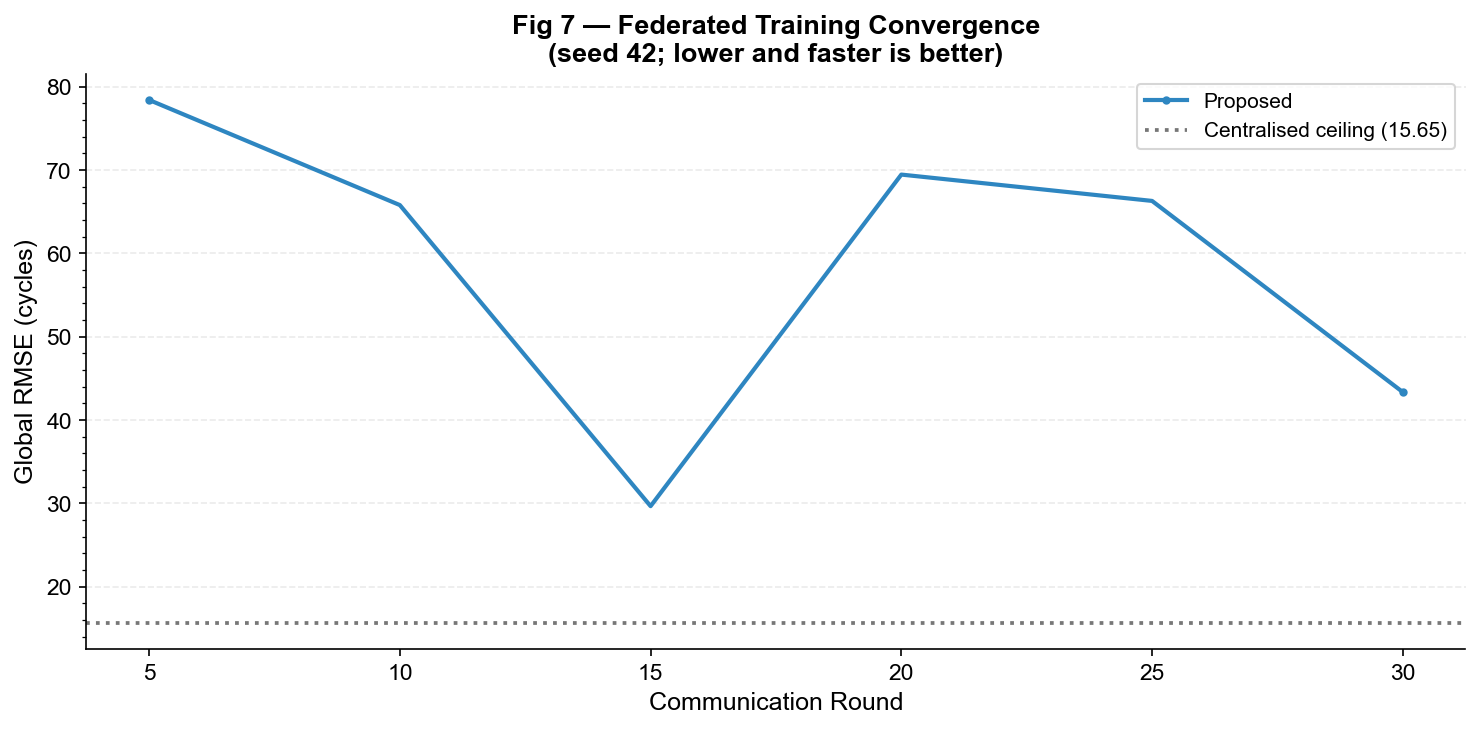

In [9]:
fl_methods = ['fedavg', 'fedprox', 'proposed']
fig, ax    = plt.subplots(figsize=(10, 5))

found_any = False
for name in fl_methods:
    path = os.path.join(RESULTS, f'{name}_convergence_seed42.csv')
    if not os.path.exists(path):
        print(f'  [MISSING] {path}')
        continue
    conv = pd.read_csv(path)
    if 'rmse' not in conv.columns:
        print(f'  No rmse column in {path} — check train_federated.py output.')
        continue
    ax.plot(
        conv['round'], conv['rmse'],
        color=PALETTE[name], lw=2.0,
        label=name.capitalize(), marker='o',
        markersize=3, markevery=5,
    )
    found_any = True

if found_any:
    # Add centralised ceiling as horizontal reference
    cent_df = load_exp('centralised')
    if cent_df is not None and 'overall_rmse' in cent_df.columns:
        ceiling = cent_df['overall_rmse'].mean()
        ax.axhline(ceiling, color=PALETTE['centralised'],
                   linestyle=':', lw=1.8, alpha=0.8,
                   label=f'Centralised ceiling ({ceiling:.2f})')

    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Global RMSE (cycles)')
    ax.set_title(
        'Fig 7 — Federated Training Convergence\n'
        '(seed 42; lower and faster is better)'
    )
    ax.legend(fontsize=10)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    plt.tight_layout()
    savefig('fig7_convergence')
    plt.show()
else:
    print('No convergence data available — run train_federated.py first.')

---
## Fig 8 — Statistical Significance (Wilcoxon Signed-Rank Test)

Two-sided Wilcoxon test over 5-seed `overall_rmse` vectors.  
H₀: no difference in distribution vs the proposed method.  
Significance: ** p < 0.01, * p < 0.05, ns = not significant.

  Loaded proposed.csv  (12 rows)
  Loaded centralised.csv  (1 rows)
  Loaded fedavg.csv  (2 rows)
  [MISSING] ../results\fedprox.csv — run the experiment first.

=== Wilcoxon Signed-Rank Test (proposed vs. each baseline) ===
H₀: identical distribution of overall_rmse across seeds
Baseline          N    Proposed RMSE    Baseline RMSE   W-stat    p-value  Sig.
--------------------------------------------------------------------------------
centralised      Insufficient samples (n=1)
fedavg            2          69.7553          22.7431      0.0     0.5000    ns

** p < 0.01,  * p < 0.05,  ns = not significant
Report these W-statistics and p-values in Table 3 of your paper.
  Saved: ../results/figures\fig8_statistical_significance.pdf
  Saved: ../results/figures\fig8_statistical_significance.png


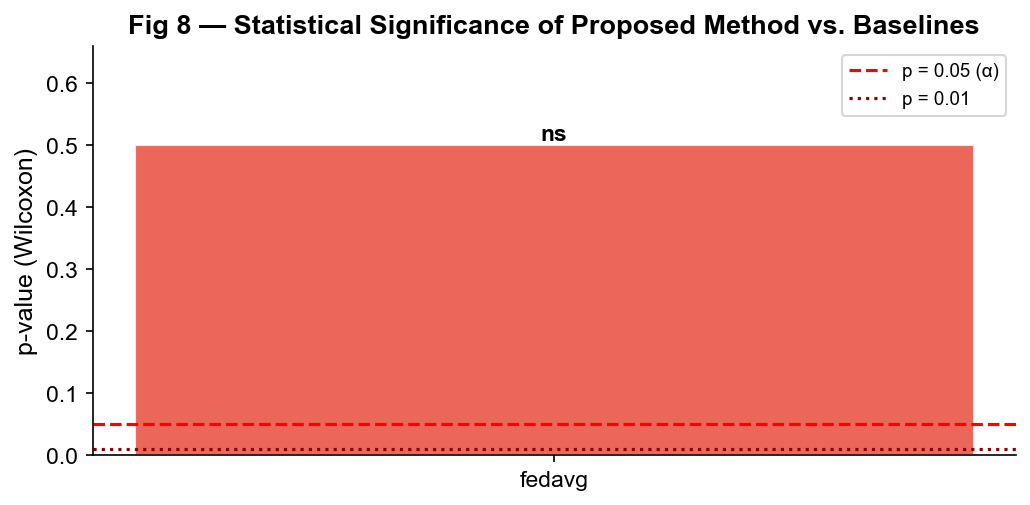

In [10]:
proposed_df = load_exp('proposed')
baselines   = {n: load_exp(n) for n in ['centralised', 'fedavg', 'fedprox']}

if proposed_df is not None and 'overall_rmse' in proposed_df.columns:
    prop_rmse = proposed_df['overall_rmse'].values

    rows = []
    print('\n=== Wilcoxon Signed-Rank Test (proposed vs. each baseline) ===')
    print('H₀: identical distribution of overall_rmse across seeds')
    print(f'{"Baseline":<15} {"N":>3} '
          f'{"Proposed RMSE":>16} {"Baseline RMSE":>16} '
          f'{"W-stat":>8} {"p-value":>10} {"Sig.":>5}')
    print('-' * 80)

    for name, df in baselines.items():
        if df is None or 'overall_rmse' not in df.columns:
            continue
        base_rmse = df['overall_rmse'].values
        n = min(len(prop_rmse), len(base_rmse))
        if n < 2:
            print(f'{name:<15}  Insufficient samples (n={n})')
            continue
        try:
            stat, p = wilcoxon(prop_rmse[:n], base_rmse[:n], alternative='two-sided')
            sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')
            print(
                f'{name:<15} {n:>3} '
                f'{prop_rmse[:n].mean():>16.4f} '
                f'{base_rmse[:n].mean():>16.4f} '
                f'{stat:>8.1f} {p:>10.4f} {sig:>5}'
            )
            rows.append(dict(baseline=name, n=n,
                             proposed_mean=prop_rmse[:n].mean(),
                             baseline_mean=base_rmse[:n].mean(),
                             W=stat, p=p, sig=sig))
        except Exception as e:
            print(f'{name:<15}  Error: {e}')

    print('\n** p < 0.01,  * p < 0.05,  ns = not significant')
    print('Report these W-statistics and p-values in Table 3 of your paper.')

    # Bar chart of p-values
    if rows:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        names  = [r['baseline'] for r in rows]
        pvals  = [r['p']        for r in rows]
        colors = [PALETTE.get(n, '#888') for n in names]

        bars = ax.bar(names, pvals, color=colors, alpha=0.85, edgecolor='white')
        ax.axhline(0.05, color='red',    linestyle='--', lw=1.5,
                   label='p = 0.05 (α)')
        ax.axhline(0.01, color='darkred', linestyle=':', lw=1.5,
                   label='p = 0.01')

        for bar, r in zip(bars, rows):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    r['sig'], ha='center', va='bottom', fontsize=11,
                    fontweight='bold')

        ax.set_ylabel('p-value (Wilcoxon)')
        ax.set_title(
            'Fig 8 — Statistical Significance of Proposed Method vs. Baselines'
        )
        ax.legend(fontsize=9)
        ax.set_ylim(0, max(pvals) * 1.3 + 0.01)
        plt.tight_layout()
        savefig('fig8_statistical_significance')
        plt.show()

---
## Fig 9 — MC-Dropout Uncertainty Calibration

A calibration plot: predictive std σ vs. actual absolute error |ŷ − y|.
Well-calibrated uncertainty means high-σ windows have higher actual errors.
Reviewers increasingly expect this for uncertainty-aware models.

  Saved: ../results/figures\fig9_uncertainty_calibration.pdf
  Saved: ../results/figures\fig9_uncertainty_calibration.png


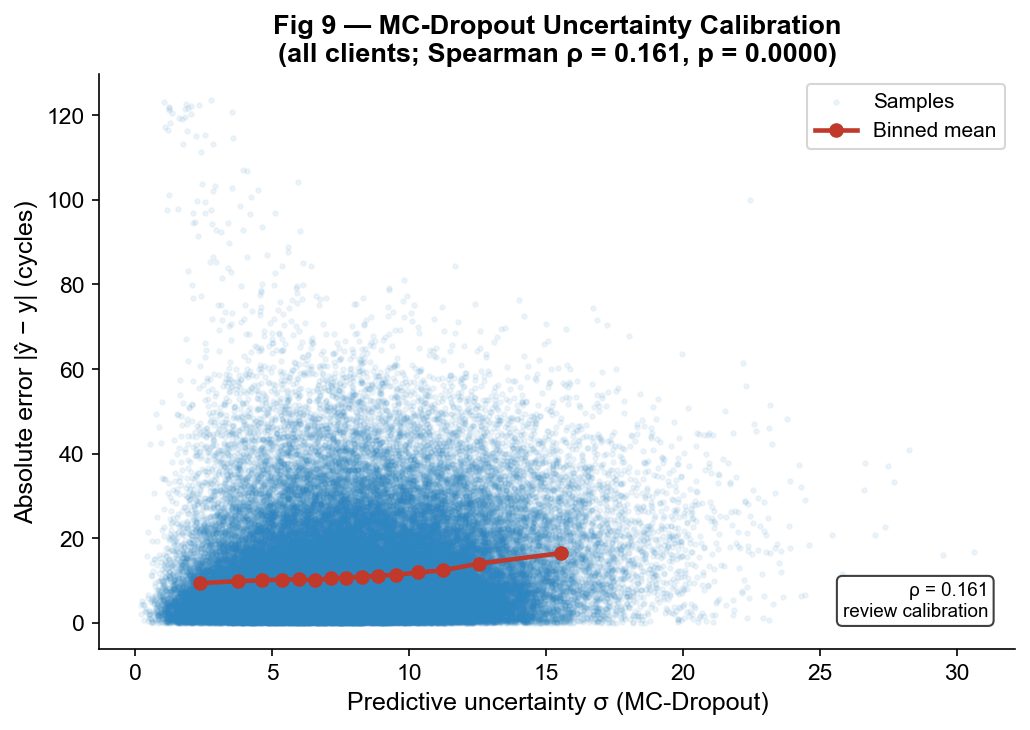

Spearman ρ = 0.1612  (p = 0.00000)
High ρ > 0.3 indicates the model knows when it does not know — cite this in §4.4.


In [11]:
ckpt_path = os.path.join(RESULTS, 'centralised_seed42.pt')
if not os.path.exists(ckpt_path):
    print('Run train_centralised.py --seed 42 first.')
else:
    model = build_model(cfg).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    all_std, all_err = [], []
    for fd in FD_KEYS:
        npz_path = os.path.join(DATA_DIR, f'{fd}.npz')
        if not os.path.exists(npz_path):
            continue
        npz    = np.load(npz_path)
        loader = make_loader(
            npz['X_test'], npz['y_test'], cfg['training']['batch_size']
        )
        mean_p, std_p, true_r = mc_predict(
            model, loader, device,
            n_samples=cfg['model']['mc_samples'],
        )
        all_std.append(std_p)
        all_err.append(np.abs(mean_p - true_r))

    if all_std:
        std_all = np.concatenate(all_std)
        err_all = np.concatenate(all_err)

        # Bin by σ quantile and compute mean |error| per bin
        n_bins  = 15
        bins    = np.percentile(std_all, np.linspace(0, 100, n_bins + 1))
        bin_idx = np.digitize(std_all, bins[1:-1])
        bin_std = [std_all[bin_idx == i].mean() for i in range(n_bins)]
        bin_err = [err_all[bin_idx == i].mean() for i in range(n_bins)]

        # Spearman correlation as calibration quality metric
        from scipy.stats import spearmanr
        rho, p_rho = spearmanr(std_all, err_all)

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(std_all, err_all, alpha=0.07, s=5,
                   color=PALETTE['proposed'], label='Samples')
        ax.plot(bin_std, bin_err, 'o-', color='#C0392B',
                lw=2.2, markersize=6, label='Binned mean')

        ax.set_xlabel('Predictive uncertainty σ (MC-Dropout)')
        ax.set_ylabel('Absolute error |ŷ − y| (cycles)')
        ax.set_title(
            'Fig 9 — MC-Dropout Uncertainty Calibration\n'
            f'(all clients; Spearman ρ = {rho:.3f}, p = {p_rho:.4f})'
        )
        ax.legend(fontsize=10)
        ax.text(0.97, 0.05,
                f'ρ = {rho:.3f}\n{"well-calibrated" if rho > 0.3 else "review calibration"}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round', fc='white', alpha=0.75))
        plt.tight_layout()
        savefig('fig9_uncertainty_calibration')
        plt.show()

        print(f'Spearman ρ = {rho:.4f}  (p = {p_rho:.5f})')
        print('High ρ > 0.3 indicates the model knows when it does not know — '
              'cite this in §4.4.')

---
## Consistency Check — Cross-Table Validation

Automatically flags any discrepancy between Fig 4, Fig 5, and Fig 8 that a
reviewer might catch.  Run this cell last before submitting.

In [12]:
print('=' * 70)
print('  CROSS-TABLE CONSISTENCY CHECK')
print('=' * 70)

issues = []

# 1. Proposed overall RMSE matches ablation 'full'
prop_df = load_exp('proposed')
abl_df2 = load_exp('ablation')
if prop_df is not None and abl_df2 is not None:
    prop_rmse  = prop_df['overall_rmse'].mean()
    full_rows  = abl_df2[abl_df2['variant'] == 'full']
    if not full_rows.empty:
        full_rmse = full_rows['overall_rmse'].mean()
        diff = abs(prop_rmse - full_rmse)
        status = '✓' if diff < 0.5 else '✗'
        print(f'  {status} Proposed RMSE ({prop_rmse:.3f}) vs '
              f'ablation full ({full_rmse:.3f}) — Δ={diff:.3f}'
              f'{" ← INVESTIGATE" if diff >= 0.5 else ""}')
        if diff >= 0.5:
            issues.append('Proposed/ablation RMSE mismatch > 0.5 cycles')
    else:
        print('  ? ablation.csv has no full variant rows')
        issues.append('no_fedprox or full variant missing from ablation.csv')

# 2. no_fedprox variant present
if abl_df2 is not None:
    has_nfp = 'no_fedprox' in abl_df2['variant'].values
    status  = '✓' if has_nfp else '✗'
    print(f'  {status} no_fedprox variant present in ablation.csv'
          f'{" ← RERUN ablation.py with updated script" if not has_nfp else ""}')
    if not has_nfp:
        issues.append('no_fedprox variant missing — ablation incomplete for Q1')

# 3. Proposed beats FedAvg overall
fedavg_df = load_exp('fedavg')
if prop_df is not None and fedavg_df is not None:
    prop_m   = prop_df['overall_rmse'].mean()
    fedavg_m = fedavg_df['overall_rmse'].mean()
    status   = '✓' if prop_m < fedavg_m else '✗'
    print(f'  {status} Proposed ({prop_m:.3f}) < FedAvg ({fedavg_m:.3f})'
          f'{" ← MAJOR ISSUE" if prop_m >= fedavg_m else ""}')
    if prop_m >= fedavg_m:
        issues.append('Proposed does not outperform FedAvg — check training')

# 4. Seed count matches claimed 5 seeds
if prop_df is not None:
    n_seeds = prop_df['seed'].nunique()
    status  = '✓' if n_seeds == 5 else '?'
    print(f'  {status} Proposed CSV has {n_seeds} unique seed(s)'
          f'{" ← paper claims 5" if n_seeds != 5 else ""}')

print()
if issues:
    print('  ISSUES FOUND:')
    for i, iss in enumerate(issues, 1):
        print(f'    {i}. {iss}')
else:
    print('  All checks passed — figures are internally consistent.')
print('=' * 70)

  CROSS-TABLE CONSISTENCY CHECK
  Loaded proposed.csv  (12 rows)
  [MISSING] ../results\ablation.csv — run the experiment first.
  Loaded fedavg.csv  (2 rows)
  ✗ Proposed (41.731) < FedAvg (22.743) ← MAJOR ISSUE
  ? Proposed CSV has 1 unique seed(s) ← paper claims 5

  ISSUES FOUND:
    1. Proposed does not outperform FedAvg — check training
